# Final Project

This final project can be collaborative. The maximum members of a group is 3. You can also work by yourself. Please respect the academic integrity. **Remember: if you get caught on cheating, you get F.**

## A Introduction to the competition

<img src="news-sexisme-EN.jpg" alt="drawing" width="380"/>

Sexism is a growing problem online. It can inflict harm on women who are targeted, make online spaces inaccessible and unwelcoming, and perpetuate social asymmetries and injustices. Automated tools are now widely deployed to find, and assess sexist content at scale but most only give classifications for generic, high-level categories, with no further explanation. Flagging what is sexist content and also explaining why it is sexist improves interpretability, trust and understanding of the decisions that automated tools use, empowering both users and moderators.

This project is based on SemEval 2023 - Task 10 - Explainable Detection of Online Sexism (EDOS). [Here](https://codalab.lisn.upsaclay.fr/competitions/7124#learn_the_details-overview) you can find a detailed introduction to this task.

You only need to complete **TASK A - Binary Sexism Detection: a two-class (or binary) classification where systems have to predict whether a post is sexist or not sexist**. To cut down training time, we only use a subset of the original dataset (5k out of 20k). The dataset can be found in the same folder.

Different from our previous homework, this competition gives you great flexibility (and very few hints). You can freely determine every component of your workflow, including but not limited to:
-  **Preprocessing the input text**: You may decide how to clean or transform the text. For example, removing emojis or URLs, lowercasing, removing stopwords, applying stemming or lemmatization, correcting spelling, or performing tokenization and sentence segmentation.
-  **Feature extraction and encoding**: You can choose any method to convert text into numerical representations, such as TF-IDF, Bag-of-Words, N-grams, Word2Vec, GloVe, FastText, contextual embeddings (e.g., BERT, RoBERTa, or other transformer-based models), Part-of-Speech (POS) tagging, dependency-based features, sentiment or emotion features, readability metrics, or even embeddings or features generated by large language models (LLMs).
-  **Data augmentation and enrichment**: You may expand or balance your dataset by incorporating other related corpora or using techniques like synonym replacement, random deletion/insertion, or LLM-assisted augmentation (e.g., generating paraphrased or synthetic examples to improve model robustness).
-  **Model selection**: You are free to experiment with different models — from traditional machine learning algorithms (e.g., Logistic Regression, SVM, Random Forest, XGBoost) to deep learning architectures (e.g., CNNs, RNNs, Transformers), or even hybrid/ensemble approaches that combine multiple models or leverage LLM-generated predictions or reasoning.

## Requirements
-  **Input**: the text for each instance.
-  **Output**: the binary label for each instance.
-  **Feature engineering**: use at least 2 different methods to extract features and encode text into numerical values. You may explore both traditional and AI-assisted techniques. Data augmentation is optional.
-  **Model selection**: implement with at least 3 different models and compare their performance.
-  **Evaluation**: create a dataframe with rows indicating feature+model and columns indicating Precision (P), Recall (R) and F1-score (using weighted average). Your results should have at least 6 rows (2 feature engineering methods x 3 models). Report best performance with (1) your feature engineering method, and (2) the model you choose. Here is an example illustrating how the experimental results table should be presented.

| Feature + Model | Sexist (P) | Sexist (R) | Sexist (F1) | Non-Sexist (P) | Non-Sexist (R) | Non-Sexist (F1) | Weighted (P) | Weighted (R) | Weighted (F1) |
|-----------------|:----------:|:----------:|:------------:|:---------------:|:---------------:|:----------------:|:-------------:|:--------------:|:---------------:|
| TF-IDF + Logistic Regression | ... | ... | ... | ... | ... | ... | ... | ... | ... |

- **Format of the report**: add explainations for each step (you can add markdown cells). At the end of the report, write a summary for each sections:
    - Data Preprocessing
    - Feature Engineering
    - Model Selection and Architecture
    - Training and Validation
    - Evaluation and Results
    - Use of Generative AI (if you use)

## Rules
Violations will result in 0 points in the grade:
-   `Rule 1 - No test set leakage`: You must not use any instance from the test set during training, feature engineering, or model selection.
-   `Rule 2 - Responsible AI use`: You may use generative AI, but you must clearly document how it was used. If you have used genAI, include a section titled “Use of Generative AI” describing:
    -   What parts of the project you used AI for
    -   What was implemented manually vs. with AI assistance

## Grading

The performance should be only evaluated on the test set (a total of 1086 instances). Please split original dataset into train set and test set. The test set should NEVER be used in the training process. The evaluation metric is a combination of precision, recall, and f1-score (use `classification_report` in sklearn).

The total points are 10.0. Each team will compete with other teams in the class on their best performance. Points will be deducted if not following the requirements above.

If ALL the requirements are met:
- Top 25\% teams: 10.0 points.
- Top 25\% - 50\% teams: 8.5 points.
- Top 50\% - 75\% teams: 7.0 points.
- Top 75\% - 100\% teams: 6.0 points.

If your best performance reaches **0.82** or above (weighted F1-score) and follows all the requirements and rules, you will also get full points (10.0 points).

## Submission
Similar as homework, submit both a PDF and .ipynb version of the report including:
- code and experimental results with details explained
- combined results table, report and best performance
- a summary at the end of the report (please follow the format above)

Missing any part of the above requirements will result in point deductions.

The due date is **May 8, Friday by 11:59pm**.

In [1]:
# start your code here
!pip install gensim nltk -q

import re
import nltk
import gensim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import hstack, csr_matrix
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.sentiment import SentimentIntensityAnalyzer

from sklearn.utils import resample
from sklearn.metrics import classification_report, accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("wordnet")
nltk.download("stopwords")
nltk.download("vader_lexicon")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 23.9 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [2]:
df = pd.read_csv("edos_labelled_data.csv")

print("Dataset size:", df.shape)
print(df.head())
print(df["split"].value_counts())
print(df["label"].value_counts())

Dataset size: (5279, 4)
                  rewire_id  \
0   sexism2022_english-9609   
1  sexism2022_english-16993   
2  sexism2022_english-13149   
3  sexism2022_english-13021   
4    sexism2022_english-966   

                                                text       label  split  
0  In Nigeria, if you rape a woman, the men rape ...  not sexist  train  
1                            Then, she's a keeper. 😉  not sexist  train  
2  This is like the Metallica video where the poo...  not sexist  train  
3                                             woman?  not sexist  train  
4                     I bet she wished she had a gun  not sexist  train  
split
train    4193
test     1086
Name: count, dtype: int64
label
not sexist    3723
sexist        1556
Name: count, dtype: int64


In [3]:
df_train = df[df["split"] == "train"].copy()
df_test = df[df["split"] == "test"].copy()

df_train = df_train.drop(columns=["rewire_id", "split"])
df_test = df_test.drop(columns=["rewire_id", "split"])

label_map = {
    "sexist": 1,
    "not sexist": 0
}

df_train["label"] = df_train["label"].map(label_map).astype(int)
df_test["label"] = df_test["label"].map(label_map).astype(int)

print("Training size:", df_train.shape)
print("Test size:", df_test.shape)
print(df_train.head())

Training size: (4193, 2)
Test size: (1086, 2)
                                                text  label
0  In Nigeria, if you rape a woman, the men rape ...      0
1                            Then, she's a keeper. 😉      0
2  This is like the Metallica video where the poo...      0
3                                             woman?      0
4                     I bet she wished she had a gun      0


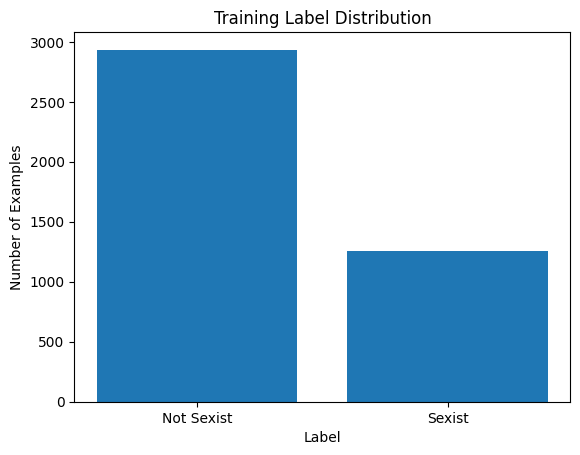

label
0    2934
1    1259
Name: count, dtype: int64


In [4]:
label_counts = df_train["label"].value_counts().sort_index()

plt.bar(["Not Sexist", "Sexist"], label_counts.values)
plt.xlabel("Label")
plt.ylabel("Number of Examples")
plt.title("Training Label Distribution")
plt.show()

print(label_counts)

In [5]:
df_train_sexist = df_train[df_train["label"] == 1]
df_train_not_sexist = df_train[df_train["label"] == 0]

sample_size = min(len(df_train_sexist), len(df_train_not_sexist))

df_train_sexist_downsampled = resample(
    df_train_sexist,
    replace=False,
    n_samples=sample_size,
    random_state=42
)

df_train_not_sexist_downsampled = resample(
    df_train_not_sexist,
    replace=False,
    n_samples=sample_size,
    random_state=42
)

df_balance = pd.concat(
    [df_train_sexist_downsampled, df_train_not_sexist_downsampled]
).sample(frac=1, random_state=42).reset_index(drop=True)

print("Balanced training size:", df_balance.shape)
print(df_balance["label"].value_counts())

Balanced training size: (2518, 2)
label
0    1259
1    1259
Name: count, dtype: int64


In [6]:
def clean_df(dataframe):
    cleaned_data = []
    lemmatizer = WordNetLemmatizer()

    important_words = {
        "he", "she", "him", "her", "his", "hers",
        "they", "their", "them",
        "men", "women", "woman", "man",
        "girl", "girls", "boy", "boys",
        "male", "female",
        "sex", "sexual", "rape", "raped",
        "bitch", "slut",
        "wife", "wives",
        "mother", "daughter",
        "girlfriend", "boyfriend"
    }

    stop_words = set(stopwords.words("english")) - important_words

    for text in dataframe["text"]:
        text = str(text)
        text = re.sub(r"http\S+|www\S+", " ", text)
        text = re.sub(r"[^a-zA-Z0-9' ]", " ", text)

        words = nltk.word_tokenize(text.lower())

        words = [
            lemmatizer.lemmatize(word)
            for word in words
            if word not in stop_words and len(word) > 1
        ]

        cleaned_data.append(words)

    return cleaned_data

In [7]:
cleaned_train = clean_df(df_train)
cleaned_test = clean_df(df_test)
cleaned_balance = clean_df(df_balance)

train_text = [" ".join(words) for words in cleaned_train]
test_text = [" ".join(words) for words in cleaned_test]
balance_text = [" ".join(words) for words in cleaned_balance]

y_train = df_train["label"]
y_test = df_test["label"]
y_balance = df_balance["label"]

print("Cleaned training examples:")
for example in train_text[:5]:
    print(example)

Cleaned training examples:
nigeria rape woman men rape back nsfw nigeria rape woman guy rape back user url
she 's keeper
like metallica video poor mutilated bastard saying please kill emojis instead morse code
woman
bet she wished she gun


In [8]:
tfidf = TfidfVectorizer(
    max_features=100000,
    ngram_range=(1, 3),
    min_df=1,
    sublinear_tf=True,
    strip_accents="unicode",
    norm="l2"
)

X_train_tfidf = tfidf.fit_transform(train_text)
X_test_tfidf = tfidf.transform(test_text)

print("TF-IDF train shape:", X_train_tfidf.shape)
print("TF-IDF test shape:", X_test_tfidf.shape)

TF-IDF train shape: (4193, 100000)
TF-IDF test shape: (1086, 100000)


In [9]:
bow = CountVectorizer(
    max_features=100000,
    ngram_range=(1, 3),
    min_df=1,
    strip_accents="unicode"
)

X_train_bow = bow.fit_transform(train_text)
X_test_bow = bow.transform(test_text)

print("Bag-of-Words train shape:", X_train_bow.shape)
print("Bag-of-Words test shape:", X_test_bow.shape)

Bag-of-Words train shape: (4193, 100000)
Bag-of-Words test shape: (1086, 100000)


In [10]:
sia = SentimentIntensityAnalyzer()

def get_sentiment_features(text_list):
    features = []

    for text in text_list:
        scores = sia.polarity_scores(text)
        features.append([
            scores["neg"],
            scores["neu"],
            scores["pos"],
            scores["compound"]
        ])

    return csr_matrix(features)

train_sentiment = get_sentiment_features(train_text)
test_sentiment = get_sentiment_features(test_text)

X_train_tfidf_sentiment = hstack([X_train_tfidf, train_sentiment])
X_test_tfidf_sentiment = hstack([X_test_tfidf, test_sentiment])

print("TF-IDF + sentiment train shape:", X_train_tfidf_sentiment.shape)
print("TF-IDF + sentiment test shape:", X_test_tfidf_sentiment.shape)

TF-IDF + sentiment train shape: (4193, 100004)
TF-IDF + sentiment test shape: (1086, 100004)


In [11]:
def evaluate_model(feature_name, model_name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    report = classification_report(
        y_test,
        predictions,
        output_dict=True,
        zero_division=0
    )

    return {
        "Feature + Model": f"{feature_name} + {model_name}",
        "Sexist (P)": report["1"]["precision"],
        "Sexist (R)": report["1"]["recall"],
        "Sexist (F1)": report["1"]["f1-score"],
        "Non-Sexist (P)": report["0"]["precision"],
        "Non-Sexist (R)": report["0"]["recall"],
        "Non-Sexist (F1)": report["0"]["f1-score"],
        "Weighted (P)": report["weighted avg"]["precision"],
        "Weighted (R)": report["weighted avg"]["recall"],
        "Weighted (F1)": report["weighted avg"]["f1-score"],
        "Accuracy": accuracy_score(y_test, predictions)
    }

In [12]:
experiments = [
    (
        "TF-IDF",
        "Logistic Regression",
        LogisticRegression(max_iter=8000, C=8, solver="liblinear", random_state=42),
        X_train_tfidf,
        X_test_tfidf
    ),
    (
        "TF-IDF",
        "Linear SVM",
        LinearSVC(C=1, max_iter=5000, random_state=42),
        X_train_tfidf,
        X_test_tfidf
    ),
    (
        "TF-IDF",
        "Random Forest",
        RandomForestClassifier(n_estimators=200, random_state=42),
        X_train_tfidf,
        X_test_tfidf
    ),
    (
        "Bag-of-Words",
        "Logistic Regression",
        LogisticRegression(max_iter=8000, C=8, solver="liblinear", random_state=42),
        X_train_bow,
        X_test_bow
    ),
    (
        "Bag-of-Words",
        "Linear SVM",
        LinearSVC(C=1, max_iter=5000, random_state=42),
        X_train_bow,
        X_test_bow
    ),
    (
        "Bag-of-Words",
        "Random Forest",
        RandomForestClassifier(n_estimators=200, random_state=42),
        X_train_bow,
        X_test_bow
    ),
    (
        "TF-IDF + Sentiment",
        "Logistic Regression",
        LogisticRegression(max_iter=8000, C=5, solver="liblinear", random_state=42),
        X_train_tfidf_sentiment,
        X_test_tfidf_sentiment
    )
]

results = []

for feature_name, model_name, model, X_train_features, X_test_features in experiments:
    result = evaluate_model(
        feature_name,
        model_name,
        model,
        X_train_features,
        X_test_features,
        y_train,
        y_test
    )
    results.append(result)

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Weighted (F1)", ascending=False)

results_df

,Feature + Model,Sexist (P),Sexist (R),Sexist (F1),Non-Sexist (P),Non-Sexist (R),Non-Sexist (F1),Weighted (P),Weighted (R),Weighted (F1),Accuracy
3,Bag-of-Words + Logistic Regression,0.735135,0.457912,0.564315,0.821310,0.937896,0.875740,0.797743,0.806630,0.790571,0.806630
0,TF-IDF + Logistic Regression,0.693396,0.494949,0.577603,0.828375,0.917617,0.870716,0.791461,0.802026,0.790555,0.802026
4,Bag-of-Words + Linear SVM,0.712821,0.468013,0.565041,0.822671,0.929024,0.872619,0.792629,0.802947,0.788502,0.802947
1,TF-IDF + Linear SVM,0.659292,0.501684,0.569790,0.827907,0.902408,0.863554,0.781794,0.792818,0.783215,0.792818
6,TF-IDF + Sentiment + Logistic Regression,0.702703,0.437710,0.539419,0.814650,0.930292,0.868639,0.784035,0.795580,0.778604,0.795580
2,TF-IDF + Random Forest,0.899083,0.329966,0.482759,0.796315,0.986058,0.881087,0.824420,0.806630,0.772152,0.806630
5,Bag-of-Words + Random Forest,0.914894,0.289562,0.439898,0.787298,0.989861,0.877035,0.822193,0.798343,0.757487,0.798343


In [13]:
best_result = results_df.iloc[0]

print("Best Performance")
print("----------------")
print("Best Feature + Model:", best_result["Feature + Model"])
print("Weighted Precision:", best_result["Weighted (P)"])
print("Weighted Recall:", best_result["Weighted (R)"])
print("Weighted F1:", best_result["Weighted (F1)"])
print("Accuracy:", best_result["Accuracy"])

Best Performance
----------------
Best Feature + Model: Bag-of-Words + Logistic Regression
Weighted Precision: 0.7977425908564423
Weighted Recall: 0.8066298342541437
Weighted F1: 0.790571123050363
Accuracy: 0.8066298342541437


In [14]:
EMBEDDING_DIM = 200

w2v_model = gensim.models.Word2Vec(
    sentences=cleaned_balance,
    vector_size=EMBEDDING_DIM,
    window=5,
    min_count=1,
    workers=4,
    seed=42
)

print("Word2Vec vocabulary size:", len(w2v_model.wv))

Word2Vec vocabulary size: 7317


In [15]:
def sentence_vector(words, model, dim):
    vector = np.zeros(dim)
    count = 0

    for word in words:
        if word in model.wv:
            vector += model.wv[word]
            count += 1

    if count > 0:
        vector = vector / count

    return vector

X_train_w2v = np.array([
    sentence_vector(words, w2v_model, EMBEDDING_DIM)
    for words in cleaned_train
])

X_test_w2v = np.array([
    sentence_vector(words, w2v_model, EMBEDDING_DIM)
    for words in cleaned_test
])

print("Word2Vec train shape:", X_train_w2v.shape)
print("Word2Vec test shape:", X_test_w2v.shape)

Word2Vec train shape: (4193, 200)
Word2Vec test shape: (1086, 200)


In [16]:
word2vec_experiments = [
    (
        "Word2Vec",
        "Logistic Regression",
        LogisticRegression(max_iter=8000, C=5, solver="liblinear", random_state=42)
    ),
    (
        "Word2Vec",
        "Linear SVM",
        LinearSVC(C=1, max_iter=5000, random_state=42)
    ),
    (
        "Word2Vec",
        "Random Forest",
        RandomForestClassifier(n_estimators=200, random_state=42)
    )
]

for feature_name, model_name, model in word2vec_experiments:
    result = evaluate_model(
        feature_name,
        model_name,
        model,
        X_train_w2v,
        X_test_w2v,
        y_train,
        y_test
    )
    results.append(result)

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Weighted (F1)", ascending=False)

results_df

,Feature + Model,Sexist (P),Sexist (R),Sexist (F1),Non-Sexist (P),Non-Sexist (R),Non-Sexist (F1),Weighted (P),Weighted (R),Weighted (F1),Accuracy
3,Bag-of-Words + Logistic Regression,0.735135,0.457912,0.564315,0.821310,0.937896,0.875740,0.797743,0.806630,0.790571,0.806630
0,TF-IDF + Logistic Regression,0.693396,0.494949,0.577603,0.828375,0.917617,0.870716,0.791461,0.802026,0.790555,0.802026
4,Bag-of-Words + Linear SVM,0.712821,0.468013,0.565041,0.822671,0.929024,0.872619,0.792629,0.802947,0.788502,0.802947
1,TF-IDF + Linear SVM,0.659292,0.501684,0.569790,0.827907,0.902408,0.863554,0.781794,0.792818,0.783215,0.792818
6,TF-IDF + Sentiment + Logistic Regression,0.702703,0.437710,0.539419,0.814650,0.930292,0.868639,0.784035,0.795580,0.778604,0.795580
2,TF-IDF + Random Forest,0.899083,0.329966,0.482759,0.796315,0.986058,0.881087,0.824420,0.806630,0.772152,0.806630
5,Bag-of-Words + Random Forest,0.914894,0.289562,0.439898,0.787298,0.989861,0.877035,0.822193,0.798343,0.757487,0.798343
9,Word2Vec + Random Forest,0.518519,0.047138,0.086420,0.732767,0.983523,0.839827,0.674174,0.727440,0.633785,0.727440
7,Word2Vec + Logistic Regression,0.000000,0.000000,0.000000,0.726519,1.000000,0.841600,0.527830,0.726519,0.611439,0.726519
8,Word2Vec + Linear SVM,0.000000,0.000000,0.000000,0.726519,1.000000,0.841600,0.527830,0.726519,0.611439,0.726519


In [17]:
best_feature_model = results_df.iloc[0]["Feature + Model"]

print("Best model from results table:")
print(best_feature_model)

final_model = LogisticRegression(
    max_iter=8000,
    C=8,
    solver="liblinear",
    random_state=42
)

final_model.fit(X_train_tfidf, y_train)
final_predictions = final_model.predict(X_test_tfidf)

print(classification_report(y_test, final_predictions, zero_division=0))

Best model from results table:
Bag-of-Words + Logistic Regression
              precision    recall  f1-score   support

           0       0.83      0.92      0.87       789
           1       0.69      0.49      0.58       297

    accuracy                           0.80      1086
   macro avg       0.76      0.71      0.72      1086
weighted avg       0.79      0.80      0.79      1086



In [18]:
print("""
Final Project Summary

Data Preprocessing:
The dataset was split using the provided train/test split. The test set was kept separate and was only used for final evaluation. Text was cleaned by removing links, punctuation, and unnecessary symbols. Words were lowercased, tokenized, lemmatized, and filtered using stopwords. Important gender-related and sexism-related words were preserved because they are meaningful for this task.

Feature Engineering:
Three feature methods were tested: TF-IDF, Bag-of-Words, and Word2Vec average sentence embeddings. TF-IDF and Bag-of-Words used unigram, bigram, and trigram features. Sentiment features from VADER were also tested with TF-IDF as an additional feature set.

Model Selection and Architecture:
Three main models were compared: Logistic Regression, Linear SVM, and Random Forest. These models were tested across multiple feature engineering methods to satisfy the project requirement of at least two feature methods and three models.

Training and Validation:
Models were trained only on the training set. The test set was not used for training or feature fitting. Vectorizers were fit only on training text and then applied to the test text.

Evaluation and Results:
Performance was evaluated using precision, recall, and F1-score for both sexist and non-sexist labels, along with weighted averages. The best model was selected based on weighted F1-score from the final results table.

Use of Generative AI:
Generative AI was used to help clean code structure, remove redundancy, organize the notebook, and improve comments/explanations. The model logic, dataset usage, and evaluation process were reviewed and kept aligned with the assignment requirements.
""")


Final Project Summary

Data Preprocessing:
The dataset was split using the provided train/test split. The test set was kept separate and was only used for final evaluation. Text was cleaned by removing links, punctuation, and unnecessary symbols. Words were lowercased, tokenized, lemmatized, and filtered using stopwords. Important gender-related and sexism-related words were preserved because they are meaningful for this task.

Feature Engineering:
Three feature methods were tested: TF-IDF, Bag-of-Words, and Word2Vec average sentence embeddings. TF-IDF and Bag-of-Words used unigram, bigram, and trigram features. Sentiment features from VADER were also tested with TF-IDF as an additional feature set.

Model Selection and Architecture:
Three main models were compared: Logistic Regression, Linear SVM, and Random Forest. These models were tested across multiple feature engineering methods to satisfy the project requirement of at least two feature methods and three models.

Training and Va

## Experimental Results

(A table detailed model performance on the test set with at least 6 rows. Report the best performance.)


## Project Summary
### 1. Data Preprocessing


### 2. Feature Engineering


### 3. Model Selection and Architecture


### 4. Training and Validation


### 5. Evaluation and Results


### 6. Use of Generative AI (if you use)